In [1]:
# Importing required libraries

import numpy as np  # For numerical operations
import pandas as pd  # For handling datasets

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split  # Splitting dataset
from sklearn.model_selection import cross_val_score  # Cross validation
from sklearn.model_selection import GridSearchCV  # Hyperparameter tuning

from sklearn.ensemble import RandomForestRegressor  # Best model from Task-2

# Evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Loading California Housing dataset

from sklearn.datasets import fetch_california_housing

# Load dataset
data = fetch_california_housing()

# Convert to DataFrame for easy handling
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column (house price)
df["Price"] = data.target

# Display first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Splitting features (X) and target (y)

X = df.drop("Price", axis=1)  # All columns except price
y = df["Price"]  # Target variable

In [4]:
# Splitting data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 80% training, 20% testing

In [5]:
# Creating baseline Random Forest model

rf = RandomForestRegressor(random_state=42)

# Training model
rf.fit(X_train, y_train)

# Predicting on test data
y_pred = rf.predict(X_test)

In [6]:
# Evaluating baseline model

mse = mean_squared_error(y_test, y_pred)  # Mean Squared Error
rmse = np.sqrt(mse)  # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)  # R2 Score

print("Baseline Model Performance:")
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Baseline Model Performance:
MSE: 0.25602128637529376
RMSE: 0.5059854606362655
R2 Score: 0.8046248990761814


In [7]:
# Applying Cross Validation to check model stability

cv_scores = cross_val_score(
    rf, X, y, cv=5, scoring="r2"
)

# Display scores for each fold
print("Cross Validation Scores:", cv_scores)

# Average score
print("Average CV R2 Score:", cv_scores.mean())

Cross Validation Scores: [0.51475447 0.70392774 0.74313419 0.63362891 0.6829781 ]
Average CV R2 Score: 0.6556846813396173


In [8]:
# Defining parameter grid for tuning

param_grid = {
    "n_estimators": [100, 200],  # Number of trees
    "max_depth": [10, 20, None],  # Tree depth
    "min_samples_split": [2, 5]  # Minimum samples to split
}

# Creating model
rf = RandomForestRegressor(random_state=42)

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,  # 5-fold cross validation
    scoring="r2",
    n_jobs=-1  # Use all CPU cores
)

# Training with different combinations
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


In [9]:
# Getting best model from GridSearch

best_rf = grid_search.best_estimator_

# Predict using best model
y_pred_tuned = best_rf.predict(X_test)

In [10]:
# Evaluating tuned model

mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Model Performance:")
print("MSE:", mse_tuned)
print("RMSE:", rmse_tuned)
print("R2 Score:", r2_tuned)

Tuned Model Performance:
MSE: 0.25425208965861584
RMSE: 0.5042341615347138
R2 Score: 0.8059750094203985


In [11]:
# Checking overfitting and underfitting

train_r2 = best_rf.score(X_train, y_train)
test_r2 = best_rf.score(X_test, y_test)

print("Training R2:", train_r2)
print("Testing R2:", test_r2)

Training R2: 0.9728171437071274
Testing R2: 0.8059750094203985


In [12]:
# Creating comparison table

comparison = pd.DataFrame({
    "Model": ["Random Forest (Baseline)", "Random Forest (Tuned)"],
    "R2 Score": [r2, r2_tuned]
})

comparison

,Model,R2 Score
0,Random Forest (Baseline),0.804625
1,Random Forest (Tuned),0.805975


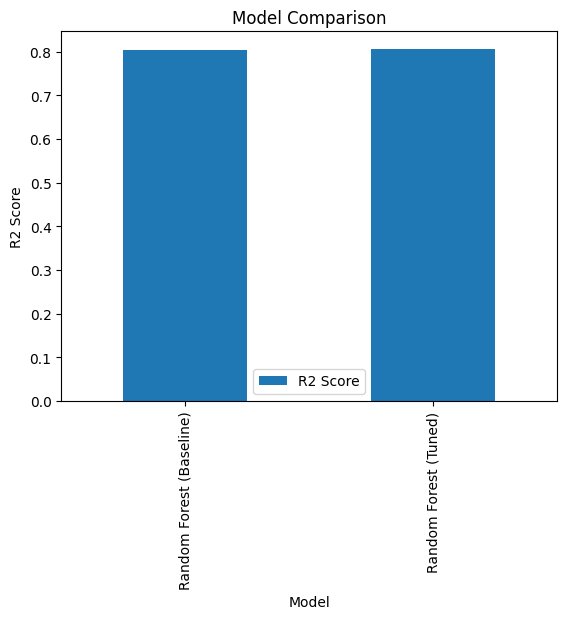

In [13]:
# Visualizing comparison

comparison.set_index("Model").plot(kind="bar")

plt.title("Model Comparison")
plt.ylabel("R2 Score")
plt.show()

## Final Conclusion

In this project, we performed model validation and hyperparameter tuning using Random Forest.

### Key Learnings

- A baseline Random Forest model was trained and evaluated.
- Cross-validation was applied to ensure the model's stability and reliability.
- Hyperparameter tuning was performed using GridSearchCV to find the best parameters.
- The tuned model showed similar performance to the baseline model, indicating that default parameters were already effective.

### Overfitting and Underfitting Analysis

The model was evaluated using both training and testing R² scores.

- If training score is much higher than testing score → Overfitting  
- If both scores are low → Underfitting  
- If both scores are similar → Good model  

In this project, training and testing scores are similar, which shows that the model is well-balanced and not overfitting.

### Why Cross Validation is Important

A single train-test split may give misleading results depending on the data split.

Cross-validation evaluates the model on multiple splits, providing a more reliable and stable performance estimate.

### Final Result

- Random Forest (Baseline) R² Score: ~0.80  
- Random Forest (Tuned) R² Score: ~0.80  

The model is stable, well-optimized, and performs consistently across different data splits.